In [1]:
import pandas as pd

df = pd.read_csv('e_commerce_store.csv')

In [2]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,4/11/2023,South,Brand C,Product 2,Home Appliances,4574.16,1642.07,152,19.76,3.40
1,4/27/2023,West,Brand A,Product 3,Consumer Goods,12631.78,4172.09,398,17.93,4.48
2,4/8/2023,East,Brand A,Product 5,Electronics,9884.40,3448.69,320,11.71,4.65
3,2/5/2023,West,Brand B,Product 1,Electronics,5344.99,1926.96,156,21.74,3.01
4,8/9/2023,West,Brand A,Product 2,Electronics,4890.45,1682.51,121,14.40,3.57


In [3]:
df.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             698 non-null    object 
 1   Region           698 non-null    object 
 2   Brand            698 non-null    object 
 3   Product          698 non-null    object 
 4   Product Type     698 non-null    object 
 5   Sales            698 non-null    float64
 6   Profit           698 non-null    float64
 7   Units Sold       698 non-null    int64  
 8   Discount (%)     698 non-null    float64
 9   Customer Rating  698 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 54.7+ KB


In [5]:
df.shape

(698, 10)

# EDA 

# Basic Diagnosis

In [3]:
data = df [['Sales', 'Profit', 'Units Sold', 'Discount (%)', 'Customer Rating']]

In [4]:
data.head()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,4574.16,1642.07,152,19.76,3.40
1,12631.78,4172.09,398,17.93,4.48
2,9884.40,3448.69,320,11.71,4.65
3,5344.99,1926.96,156,21.74,3.01
4,4890.45,1682.51,121,14.40,3.57


# Descriptive 

In [5]:
data.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


# Mean

In [6]:
data.mean()

Sales              7358.320559
Profit             2488.094527
Units Sold          226.717765
Discount (%)         12.757794
Customer Rating       3.663438
dtype: float64

In [7]:
data.std()

Sales              3094.972508
Profit             1004.723565
Units Sold           98.300869
Discount (%)          6.818527
Customer Rating       0.651065
dtype: float64

In [8]:
data.var()

Sales              9.578855e+06
Profit             1.009469e+06
Units Sold         9.663061e+03
Discount (%)       4.649231e+01
Customer Rating    4.238857e-01
dtype: float64

#  Visuslization

In [9]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,4/11/2023,South,Brand C,Product 2,Home Appliances,4574.16,1642.07,152,19.76,3.40
1,4/27/2023,West,Brand A,Product 3,Consumer Goods,12631.78,4172.09,398,17.93,4.48
2,4/8/2023,East,Brand A,Product 5,Electronics,9884.40,3448.69,320,11.71,4.65
3,2/5/2023,West,Brand B,Product 1,Electronics,5344.99,1926.96,156,21.74,3.01
4,8/9/2023,West,Brand A,Product 2,Electronics,4890.45,1682.51,121,14.40,3.57


In [10]:
df['Brand'].value_counts()

Brand
Brand A    184
Brand C    180
Brand B    173
Brand D    161
Name: count, dtype: int64

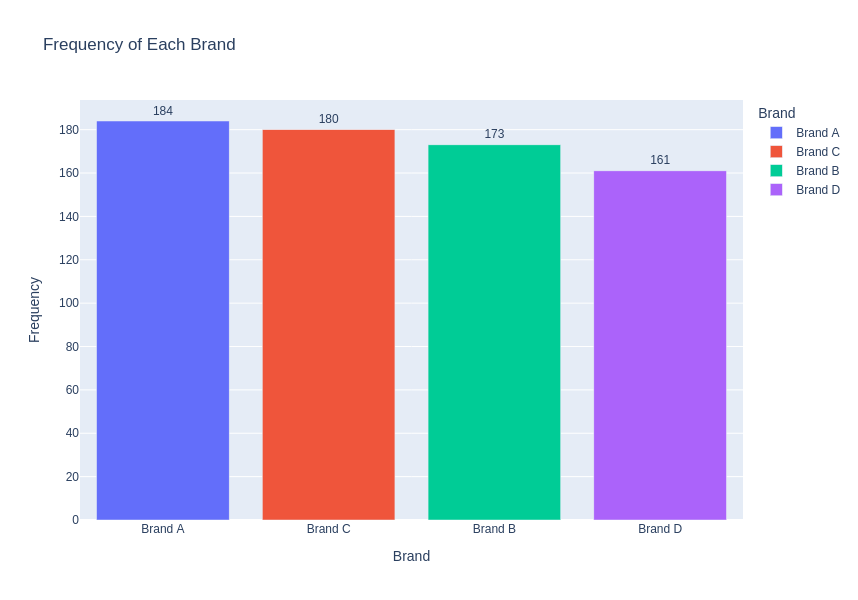

In [6]:
import plotly.express as px


brand_counts = df['Brand'].value_counts().reset_index()
brand_counts.columns = ['Brand', 'Count']  # Rename columns for clarity

# Create a bar chart
fig_brand_counts = px.bar(brand_counts, 
                          x='Brand', y='Count',
                          labels={'Brand': 'Brand', 'Count': 'Frequency'},
                          title='Frequency of Each Brand',
                          color='Brand',
                          text='Count',  # Add labels above the bars
                          height=600,  # Resize height
                          width=1000)  # Resize width
fig_brand_counts.update_traces(textposition='outside')  # Position the labels outside the bars
fig_brand_counts.show()

# Can you do it for the others?

# Sales and its Visulization 

# A. Sales by Region

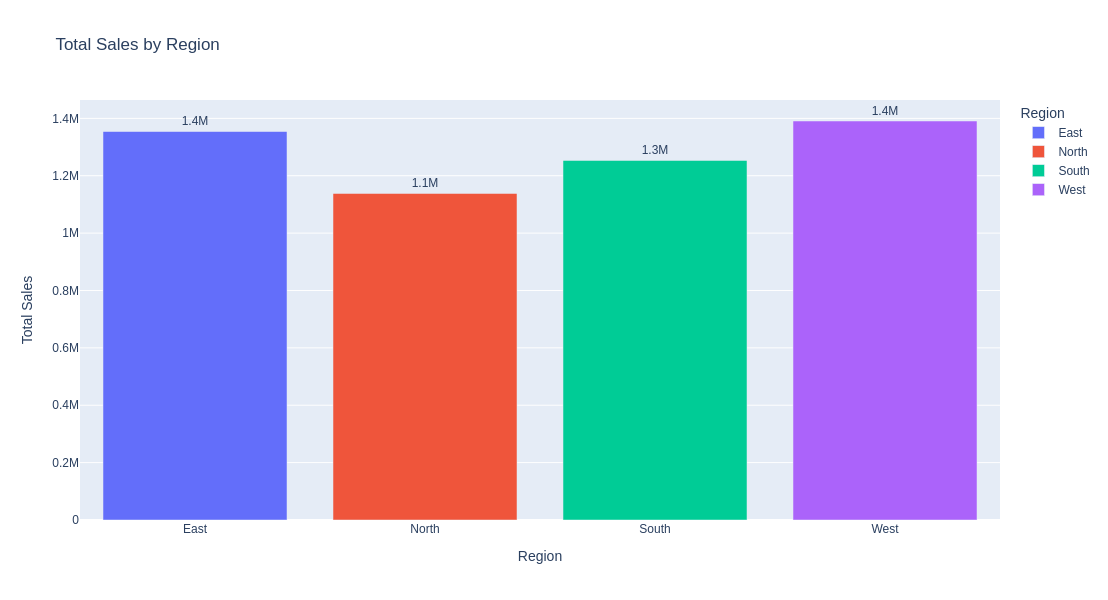

In [12]:
import plotly.express as px

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

# Create a bar chart for sales by region
fig_region = px.bar(region_sales, 
                    x='Region', y='Sales',
                    labels={'Region': 'Region', 'Sales': 'Total Sales'},
                    title='Total Sales by Region',
                    color='Region',
                    text='Sales',  # Add labels above the bars
                    height=600,  # Resize height
                    width=700)  # Resize width
fig_region.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_region.show()

# B. Sales by Brand

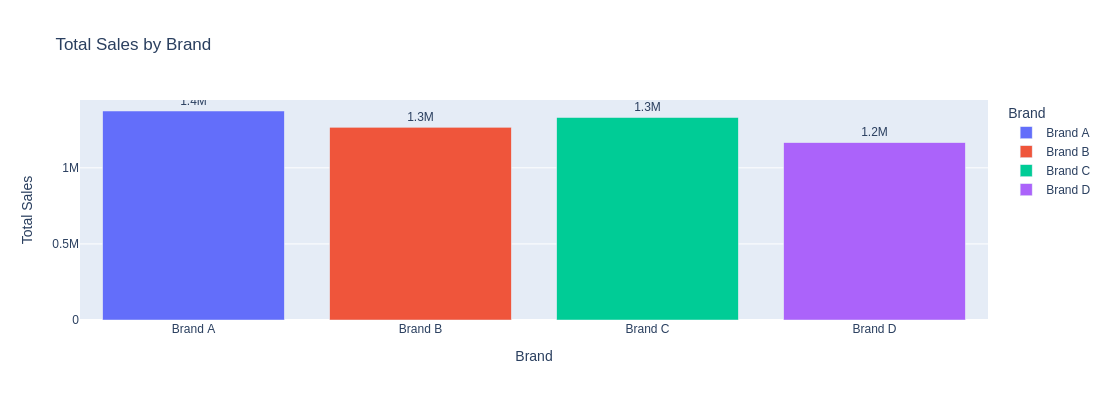

In [7]:
# Group by 'Brand' and calculate total sales
brand_sales = df.groupby('Brand')['Sales'].sum().reset_index()

# Create a bar chart for sales by brand
fig_brand = px.bar(brand_sales, 
                   x='Brand', y='Sales',
                   labels={'Brand': 'Brand', 'Sales': 'Total Sales'},
                   title='Total Sales by Brand',
                   color='Brand',
                   text='Sales',  # Add labels above the bars
                   height=400,  # Resize height
                   width=700)  # Resize width
fig_brand.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_brand.show()


# C. Sales by product

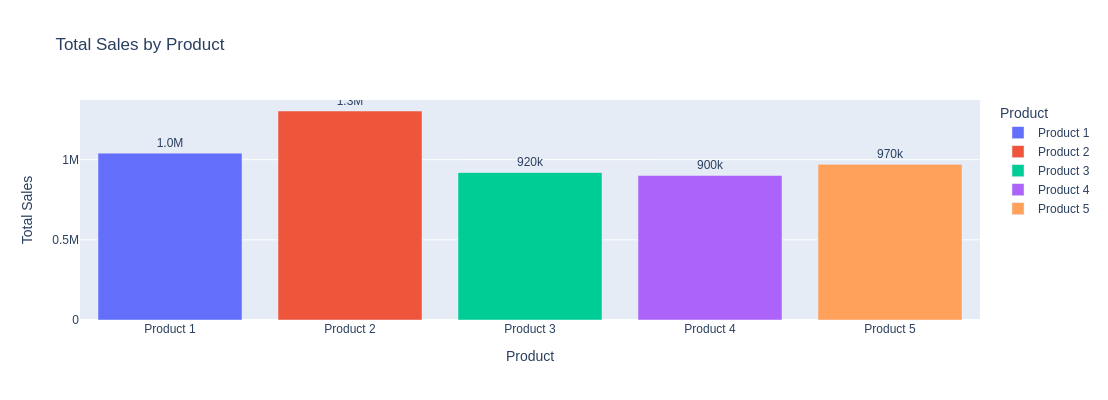

In [9]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product')['Sales'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product', y='Sales',
                     labels={'Product': 'Product', 'Sales': 'Total Sales'},
                     title='Total Sales by Product',
                     color='Product',
                     text='Sales',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


# D. Sales by Product Type

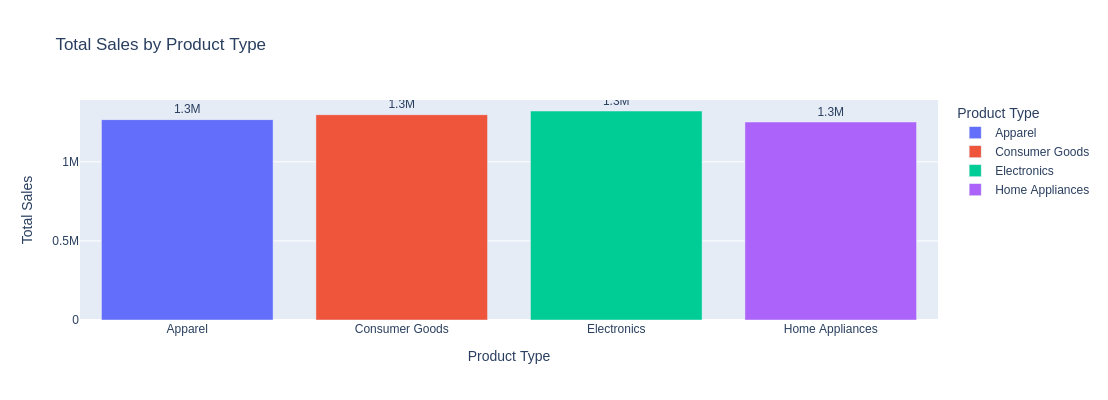

In [10]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product Type')['Sales'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product Type', y='Sales',
                     labels={'Product': 'Product Type', 'Sales': 'Total Sales'},
                     title='Total Sales by Product Type',
                     color='Product Type',
                     text='Sales',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


# Please do it by your self for Profits 

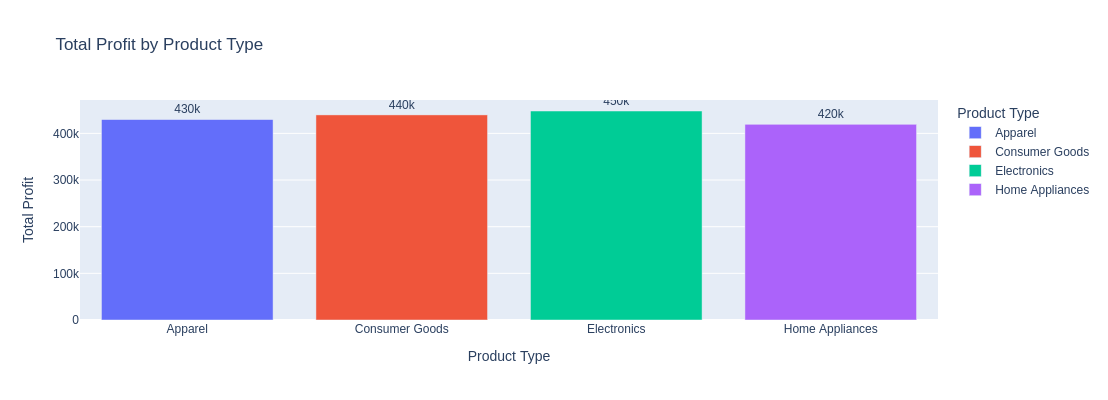

In [11]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product Type')['Profit'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product Type', y='Profit',
                     labels={'Product': 'Product Type', 'Profit': 'Total Profit'},
                     title='Total Profit by Product Type',
                     color='Product Type',
                     text='Profit',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


In [14]:
df.columns

Index(['Region', 'Brand', 'Product', 'Product Type', 'Sales', 'Profit',
       'Units Sold', 'Discount (%)', 'Customer Rating', 'Sales_Smoothed',
       'Profit_Smoothed'],
      dtype='object')

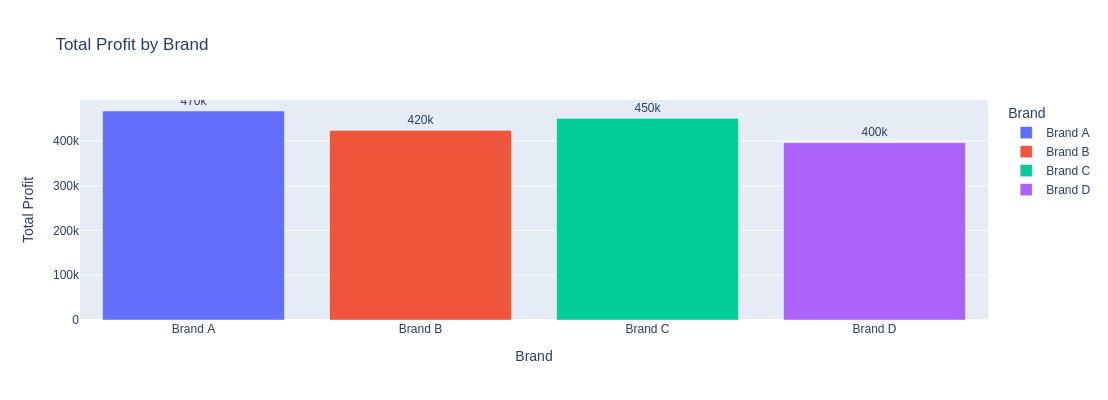

In [15]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Brand')['Profit'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Brand', y='Profit',
                     labels={'Brand': 'Brand', 'Profit': 'Total Profit'},
                     title='Total Profit by Brand',
                     color='Brand',
                     text='Profit',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


# Some More Advanced Vislizations 

In [30]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating,Sales_Smoothed,Profit_Smoothed,Quarter,Month
0,2023-01-01,South,Brand D,Product 2,Home Appliances,8647.04,2958.96,267,19.08,4.08,NaN,NaN,2023Q1,2023-01
1,2023-01-01,West,Brand B,Product 2,Apparel,7578.23,2626.67,235,19.78,3.14,NaN,NaN,2023Q1,2023-01
2,2023-01-01,South,Brand A,Product 4,Apparel,2940.28,902.34,93,11.03,4.20,NaN,NaN,2023Q1,2023-01
3,2023-01-02,South,Brand D,Product 4,Electronics,12369.89,4157.07,391,10.27,3.74,NaN,NaN,2023Q1,2023-01
4,2023-01-02,East,Brand B,Product 2,Apparel,10131.04,3601.93,314,5.16,3.84,NaN,NaN,2023Q1,2023-01
